# TRANSFER LEARNING USING PRE-TRAINED VISION MODELS FOR IMAGE RECOGNITION
by Rohith John 24BAD100

# Part A: Dataset Preparation
## Importing Dog and Cat dataset from local storage

In [1]:
import os
import tensorflow as tf
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
TRAIN_PATH = r"/kaggle/input/datasets/jakupymeraj/cats-and-dogs-image-dataset/dataset/training_set"
TEST_PATH = r"/kaggle/input/datasets/jakupymeraj/cats-and-dogs-image-dataset/dataset/test_set"
print("Training folder:", TRAIN_PATH)
print("Testing folder:", TEST_PATH)

Training folder: /kaggle/input/datasets/jakupymeraj/cats-and-dogs-image-dataset/dataset/training_set
Testing folder: /kaggle/input/datasets/jakupymeraj/cats-and-dogs-image-dataset/dataset/test_set


## Splitting Dataset in train, test and validation sets:

In [2]:
import tensorflow as tf
import os
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

Found 8000 files belonging to 2 classes.
Using 6400 files for training.


2026-08-16 17:08:33.008990: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 8000 files belonging to 2 classes.
Using 1600 files for validation.
Found 2000 files belonging to 2 classes.


In [3]:
#Check class names
print("Class names:", train_ds.class_names)

Class names: ['cats', 'dogs']


In [4]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("Dataset preprocessing completed successfully.")

Dataset preprocessing completed successfully.


# PART B: IMPLEMENTING TRANSFER LEARNING
## Loading the Pre-trained ResNet-50 Model

In [8]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights="/kaggle/input/models/mrohithjohn/resnet50/keras/default/1/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("ResNet-50 loaded successfully.")

ResNet-50 loaded successfully.


## Freezing the Feature Extraction Layers

In [9]:
base_model.trainable = False

print("Base model trainable:", base_model.trainable)

Base model trainable: False


## Replacing the Final Classification Layer

In [10]:
from tensorflow.keras import layers, models

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Compiling the Transfer Learning Model

In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


# PART C: MODEL TRAINING AND PERFORMANCE EVALUATION
## Training the Transfer Learning Model

In [12]:
EPOCHS = 5
history = model.fit(
    train_ds,
    validation_data=val_ds, 
    epochs=EPOCHS
)

Epoch 1/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 490s 1s/step - accuracy: 0.9458 - loss: 0.1372 - val_accuracy: 0.9769 - val_loss: 0.0617
Epoch 2/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 535s 1s/step - accuracy: 0.9794 - loss: 0.0553 - val_accuracy: 0.9762 - val_loss: 0.0549
Epoch 3/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 485s 1s/step - accuracy: 0.9834 - loss: 0.0440 - val_accuracy: 0.9781 - val_loss: 0.0538
Epoch 4/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 502s 1s/step - accuracy: 0.9858 - loss: 0.0356 - val_accuracy: 0.9769 - val_loss: 0.0510
Epoch 5/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 531s 1s/step - accuracy: 0.9905 - loss: 0.0270 - val_accuracy: 0.9819 - val_loss: 0.0530


## Recording Training and Validation Performance

In [13]:
history_df = pd.DataFrame(history.history)

print(history_df)

   accuracy      loss  val_accuracy  val_loss
0  0.945781  0.137220      0.976875  0.061687
1  0.979375  0.055323      0.976250  0.054891
2  0.983437  0.044038      0.978125  0.053793
3  0.985781  0.035587      0.976875  0.050974
4  0.990469  0.026975      0.981875  0.052971


## Accuracy vs Epoch

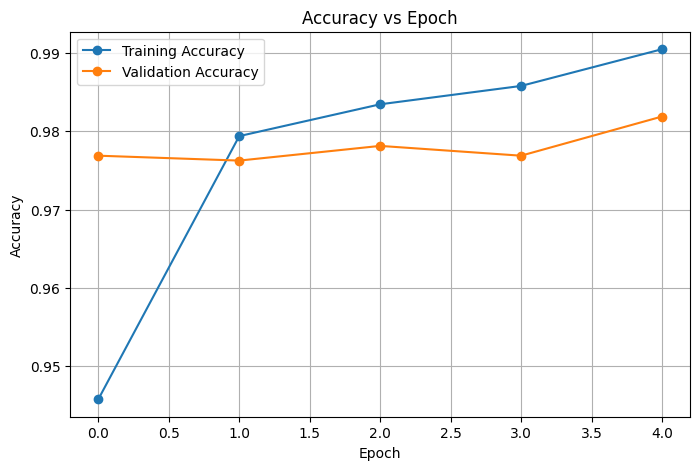

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

## Loss vs Epoch

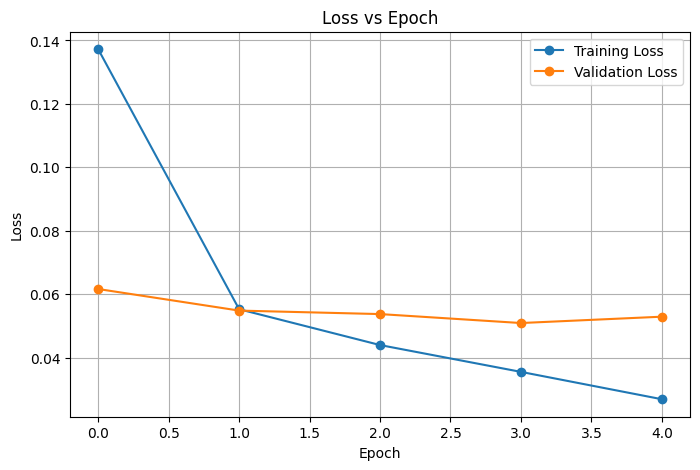

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

## Evaluating the Model on the Test Dataset

In [16]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

125/125 ━━━━━━━━━━━━━━━━━━━━ 123s 980ms/step - accuracy: 0.9820 - loss: 0.0541
Test Loss: 0.05410528555512428
Test Accuracy: 0.9819999933242798
Test Accuracy (%): 98.19999933242798


In [70]:
# Recreate the TensorFlow Transfer Learning Model

from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

tf_base_model = ResNet50(
    weights="/kaggle/input/models/mrohithjohn/resnet50/keras/default/1/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze ResNet-50 feature extraction layers
tf_base_model.trainable = False

# Create the TensorFlow transfer learning model
tf_model = models.Sequential([
    tf_base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

# Compile
tf_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("TensorFlow Transfer Learning Model recreated successfully.")

TensorFlow Transfer Learning Model recreated successfully.


In [73]:
# Train the TensorFlow Transfer Learning Model

tf_history = tf_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 543s 1s/step - accuracy: 0.9616 - loss: 0.1020 - val_accuracy: 0.9756 - val_loss: 0.0633
Epoch 2/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 532s 1s/step - accuracy: 0.9817 - loss: 0.0497 - val_accuracy: 0.9787 - val_loss: 0.0565
Epoch 3/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 481s 1s/step - accuracy: 0.9834 - loss: 0.0426 - val_accuracy: 0.9712 - val_loss: 0.0708
Epoch 4/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 487s 1s/step - accuracy: 0.9870 - loss: 0.0341 - val_accuracy: 0.9663 - val_loss: 0.1179
Epoch 5/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 489s 1s/step - accuracy: 0.9895 - loss: 0.0257 - val_accuracy: 0.9769 - val_loss: 0.0684


In [75]:
# Evaluate the TensorFlow Transfer Learning Model

tf_test_loss, tf_test_accuracy = tf_model.evaluate(test_ds)

print("TensorFlow Test Accuracy:", tf_test_accuracy * 100, "%")

125/125 ━━━━━━━━━━━━━━━━━━━━ 122s 979ms/step - accuracy: 0.9785 - loss: 0.0712
TensorFlow Test Accuracy: 97.85000085830688 %


# PART D: USING HUGGING FACE PRE-TRAINED MODELS

In [17]:
!pip install -U transformers huggingface_hub pillow

^C


In [44]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from transformers import AutoImageProcessor, ResNetForImageClassification

MODEL_PATH = "/kaggle/input/datasets/mrohithjohn/huggingface-resnet50-weight"

DATASET_PATH = "/kaggle/input/datasets/jakupymeraj/cats-and-dogs-image-dataset/dataset"

TRAIN_PATH = os.path.join(DATASET_PATH, "training_set")
TEST_PATH = os.path.join(DATASET_PATH, "test_set")

print("Model path:", MODEL_PATH)
print("Training path:", TRAIN_PATH)
print("Testing path:", TEST_PATH)

Model path: /kaggle/input/datasets/mrohithjohn/huggingface-resnet50-weight
Training path: /kaggle/input/datasets/jakupymeraj/cats-and-dogs-image-dataset/dataset/training_set
Testing path: /kaggle/input/datasets/jakupymeraj/cats-and-dogs-image-dataset/dataset/test_set


## Load Hugging Face processor

In [45]:
processor = AutoImageProcessor.from_pretrained(
    MODEL_PATH,
    local_files_only=True
)

print("Image processor loaded successfully.")
print(processor)

Image processor loaded successfully.
ConvNextImageProcessorFast {
  "crop_pct": 0.875,
  "data_format": "channels_first",
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "ConvNextImageProcessorFast",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 224
  }
}



## Load ResNet-50 and change it to 2 classes

In [46]:
hf_model = ResNetForImageClassification.from_pretrained(
    MODEL_PATH,
    num_labels=2,
    ignore_mismatched_sizes=True,
    local_files_only=True
)

hf_model.config.id2label = {
    0: "CAT",
    1: "DOG"
}

hf_model.config.label2id = {
    "CAT": 0,
    "DOG": 1
}

print("Hugging Face ResNet-50 loaded successfully.")
print("Number of classes:", hf_model.config.num_labels)

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

ResNetForImageClassification LOAD REPORT from: /kaggle/input/datasets/mrohithjohn/huggingface-resnet50-weight
Key                 | Status   |                                                                                          
--------------------+----------+------------------------------------------------------------------------------------------
classifier.1.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 2048]) vs model:torch.Size([2, 2048])
classifier.1.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])            

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Hugging Face ResNet-50 loaded successfully.
Number of classes: 2


## Loading the Hugging Face Pre-trained ResNet-50 Model
### Prepare the Dataset for PyTorch

In [47]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch

# Image preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load training and testing datasets
hf_train_dataset = datasets.ImageFolder(
    TRAIN_PATH,
    transform=transform
)

hf_test_dataset = datasets.ImageFolder(
    TEST_PATH,
    transform=transform
)

# Create DataLoaders
hf_train_loader = DataLoader(
    hf_train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2
)

hf_test_loader = DataLoader(
    hf_test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

print("Classes:", hf_train_dataset.classes)
print("Training images:", len(hf_train_dataset))
print("Testing images:", len(hf_test_dataset))

Classes: ['cats', 'dogs']
Training images: 8000
Testing images: 2000


## Freezing the Pre-trained Feature Extraction Layers

In [48]:
# Freeze the pre-trained ResNet-50 backbone
for param in hf_model.resnet.parameters():
    param.requires_grad = False

# Keep only the new classification layer trainable
for param in hf_model.classifier.parameters():
    param.requires_grad = True

# Display trainable parameters
trainable_params = sum(
    p.numel() for p in hf_model.parameters() if p.requires_grad
)

total_params = sum(
    p.numel() for p in hf_model.parameters()
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 23512130
Trainable parameters: 4098


## Training the Hugging Face ResNet-50 Model

In [49]:
import torch.nn as nn
import torch.optim as optim

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

hf_model = hf_model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(
    hf_model.classifier.parameters(),
    lr=0.001
)

EPOCHS_HF = 5

train_losses = []
train_accuracies = []

for epoch in range(EPOCHS_HF):

    hf_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in hf_train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = hf_model(pixel_values=images)

        loss = criterion(outputs.logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        predictions = torch.argmax(outputs.logits, dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(hf_train_loader)
    epoch_accuracy = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch {epoch + 1}/{EPOCHS_HF} "
        f"- Loss: {epoch_loss:.4f} "
        f"- Accuracy: {epoch_accuracy:.4f}"
    )

Using device: cpu
Epoch 1/5 - Loss: 0.1901 - Accuracy: 0.9501
Epoch 2/5 - Loss: 0.0965 - Accuracy: 0.9691
Epoch 3/5 - Loss: 0.0781 - Accuracy: 0.9739
Epoch 4/5 - Loss: 0.0663 - Accuracy: 0.9759
Epoch 5/5 - Loss: 0.0651 - Accuracy: 0.9765


## Evaluating the Hugging Face Model on the Test Dataset

In [51]:
hf_model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in hf_test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = hf_model(pixel_values=images)

        predictions = torch.argmax(outputs.logits, dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

hf_test_accuracy = correct / total

print("Hugging Face Test Accuracy:", hf_test_accuracy)
print("Hugging Face Test Accuracy (%):", hf_test_accuracy * 100)

Hugging Face Test Accuracy: 0.9855
Hugging Face Test Accuracy (%): 98.55000000000001


## Hugging Face Training Accuracy

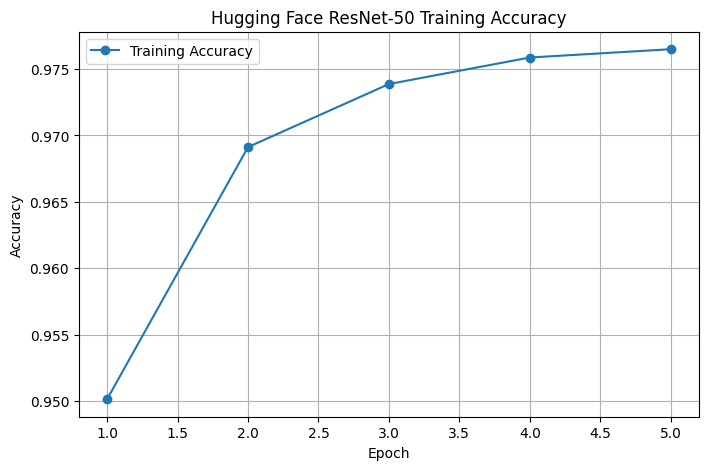

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS_HF + 1),
    train_accuracies,
    marker="o",
    label="Training Accuracy"
)

plt.title("Hugging Face ResNet-50 Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

## Image Classification Using the Hugging Face Model

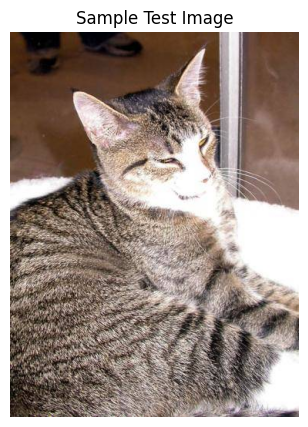

Actual Class: cats


In [76]:
import random
import os
import matplotlib.pyplot as plt
from PIL import Image

# Select a random image from the test dataset
sample_class = random.choice(["cats", "dogs"])

sample_folder = os.path.join(
    TEST_PATH,
    sample_class
)

sample_image_name = random.choice(
    os.listdir(sample_folder)
)

sample_image_path = os.path.join(
    sample_folder,
    sample_image_name
)

# Load image
sample_image = Image.open(
    sample_image_path
).convert("RGB")

# Display image
plt.figure(figsize=(5, 5))
plt.imshow(sample_image)
plt.axis("off")
plt.title("Sample Test Image")
plt.show()

print("Actual Class:", sample_class)

In [77]:
# Prepare image for Hugging Face model

inputs = processor(
    images=sample_image,
    return_tensors="pt"
)

inputs = {
    key: value.to(device)
    for key, value in inputs.items()
}

# Make prediction
hf_model.eval()

with torch.no_grad():
    outputs = hf_model(**inputs)

probabilities = torch.softmax(
    outputs.logits,
    dim=1
)

predicted_class_id = torch.argmax(
    probabilities,
    dim=1
).item()

predicted_class = hf_model.config.id2label[
    predicted_class_id
]

hf_confidence = probabilities[
    0,
    predicted_class_id
].item()

print("Hugging Face Prediction:", predicted_class)
print("Confidence:", round(hf_confidence * 100, 2), "%")

Hugging Face Prediction: CAT
Confidence: 98.59 %


## Comparing Hugging Face and Transfer Learning Predictions

In [78]:
import numpy as np
import tensorflow as tf

# Convert PIL image to NumPy array
tf_image = np.array(sample_image)

# Resize image
tf_image = tf.image.resize(
    tf_image,
    (224, 224)
)

# Convert to float
tf_image = tf.cast(
    tf_image,
    tf.float32
)

# Add batch dimension
tf_image = tf.expand_dims(
    tf_image,
    axis=0
)

# Predict using TensorFlow model
tf_prediction = tf_model.predict(
    tf_image,
    verbose=0
)

# Extract probability
tf_probability = float(
    np.asarray(tf_prediction).reshape(-1)[0]
)

# Convert probability to class
if tf_probability >= 0.5:
    tf_class = "dogs"
    tf_confidence = tf_probability
else:
    tf_class = "cats"
    tf_confidence = 1 - tf_probability

print("Actual Class:", sample_class)

print("\nTensorFlow Transfer Learning Model:")
print("Prediction:", tf_class)
print("Confidence:", round(tf_confidence * 100, 2), "%")

print("\nHugging Face ResNet-50:")
print("Prediction:", predicted_class.lower())
print("Confidence:", round(hf_confidence * 100, 2), "%")

Actual Class: cats

TensorFlow Transfer Learning Model:
Prediction: cats
Confidence: 100.0 %

Hugging Face ResNet-50:
Prediction: cat
Confidence: 98.59 %


### Prediction Comparison

In [79]:
import pandas as pd

prediction_comparison = pd.DataFrame({
    "Model": [
        "TensorFlow Transfer Learning ResNet-50",
        "Hugging Face ResNet-50"
    ],
    "Actual Class": [
        sample_class,
        sample_class
    ],
    "Predicted Class": [
        tf_class,
        predicted_class.lower()
    ],
    "Confidence (%)": [
        round(tf_confidence * 100, 2),
        round(hf_confidence * 100, 2)
    ]
})

prediction_comparison

,Model,Actual Class,Predicted Class,Confidence (%)
0,TensorFlow Transfer Learning ResNet-50,cats,cats,100.00
1,Hugging Face ResNet-50,cats,cat,98.59


In [80]:
# Test accuracy comparison

print(
    f"TensorFlow ResNet-50 Test Accuracy: "
    f"{tf_test_accuracy * 100:.2f}%"
)

print(
    f"Hugging Face ResNet-50 Test Accuracy: "
    f"{hf_test_accuracy * 100:.2f}%"
)

TensorFlow ResNet-50 Test Accuracy: 97.85%
Hugging Face ResNet-50 Test Accuracy: 98.55%
